# CreditRisk360 — Fase 1: Análisis Exploratorio de Datos (EDA)
**Dataset:** LendingClub Loan Data 2007-2018  
**Autor:** Rolando Rodriguez  
**Fecha:** 2026

## CreditRisk360 — Resumen Ejecutivo EDA
Dataset   : LendingClub 2007-2018                          
Muestra   : 549.566 préstamos (40% estratificado)          
Variables : 37 columnas seleccionadas de 151 originales

ESTADÍSTICAS BASE DE CARTERA                               
Total préstamos modelizables : 549.566                     
Tasa de default              : 21.5%                       
Período analizado            : Jun 2007 — Dic 2018   

HALLAZGOS PRINCIPALES                                      

1. GRADE — discriminación perfectamente monotónica         
   Grade A: 6.7% default → Grade G: 50.4% default          
   Diferencia: 43.7 puntos porcentuales                    

2. DTI — relación monotónica con umbral relevante          
   DTI 0-10%: 16.4% default                                
   DTI 50%+ : 37.2% default                                
   Aceleración significativa a partir de DTI > 15%         
                                                         
3. FICO — poder discriminante con sesgo de selección       
   FICO 640-660: 28.8% default                             
   FICO 770+   :  8.5% default                             
   Piso mínimo LendingClub ~610 — rango comprimido          
   
4. PROPÓSITO — small_business lidera el riesgo              
   Small business: 31.3% — mayor tasa de la cartera         
   Debt consolidation: 22.7% — 58% del volumen total        
   Concentración: 79.9% en solo 2 propósitos                
                                                           
5. TEMPORAL — efecto vintage contraintuitivo                
   Vintages crisis (2009): 12.8% — selección conservadora   
   Vintages expansión (2017): 27.3% — relajación estándares 
   Análisis confiable desde 2010 (n > 5.000) 

DECISIONES METODOLÓGICAS                                    
  · Default = Charged Off + Late >16d + Does not meet policy  
  · Desbalance 78.5%/21.5% → métricas: ROC-AUC y KS          
  · DTI > 100 eliminado (valores centinela, n=233, 0.04%)     
  · FICO tramo 610-640 estadísticamente no representativo     
  · Años 2007-2009 orientativos por volumen insuficiente   

  PRÓXIMA FASE                                                
  Semana 2 — Construcción modelo PD                          
 · Regresión logística (baseline regulatorio)                
 · XGBoost (performance)                                     
 · Métricas: ROC-AUC, KS Statistic, Calibración

## 1. Configuración del entorno y carga de datos
### 1.1 Librerías
### 1.2 Carga optimizada del dataset
### 1.3 Definición formal de default

## 2. Análisis de la variable objetivo
### 2.1 Distribución de loan_status
### 2.2 Tasa de default por grade

## 3. Análisis de variables predictoras clave
### 3.1 DTI — Ratio deuda/ingreso
### 3.2 FICO score
### 3.3 Propósito del préstamo

## 4. Análisis temporal — efecto vintage
### 4.1 Evolución del default por año
### 4.2 Implicaciones para stress testing

## 5. Decisiones metodológicas y próximos pasos
### 5.1 Supuestos documentados
### 5.2 Variables seleccionadas para modelo PD
### 5.3 Guardado del dataset procesado

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [ ]:
cols_target = [
    'id', 'loan_amnt', 'funded_amnt', 'term',
    'int_rate', 'installment', 'issue_d', 'loan_status'
]

cols_borrower = [
    'grade', 'sub_grade', 'emp_length', 'home_ownership',
    'annual_inc', 'verification_status', 'purpose',
    'dti', 'delinq_2yrs', 'earliest_cr_line',
    'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq',
    'open_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'total_acc', 'application_type',
    'mort_acc', 'pub_rec_bankruptcies'
]

cols_performance = [
    'out_prncp', 'total_pymnt', 'total_rec_prncp',
    'total_rec_int', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_amnt'
]

cols_seleccionadas = cols_target + cols_borrower + cols_performance

# ── Paso 1: cargar solo loan_status para estratificar ──
print("Leyendo loan_status para estratificación...")
df_status = pd.read_csv('accepted_2007_to_2018Q4.csv', usecols=['loan_status'], low_memory=False)

# ── Paso 2: definir qué estados son modelizables ──
# Excluimos Current, In Grace Period, Late — no tienen resultado final conocido
estados_modelizables = [
    'Fully Paid',
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)',   # los trataremos como default
    'Late (16-30 days)'    # los trataremos como default
]

mask_modelizable = df_status['loan_status'].isin(estados_modelizables)
indices_modelizables = df_status[mask_modelizable].index

print(f"Préstamos modelizables: {len(indices_modelizables):,}")
print(f"Excluidos (Current, etc.): {(~mask_modelizable).sum():,}")

# ── Paso 3: muestra estratificada por loan_status ──
# Tomamos el 40% manteniendo proporciones de cada clase
# Esto nos dará ~550k filas — manejable con 8GB
df_status_model = df_status.loc[indices_modelizables]

sample_indices = (
    df_status_model
    .groupby('loan_status', group_keys=False)
    .apply(lambda x: x.sample(frac=0.40, random_state=42))
    .index
)

print(f"\nTamaño de muestra: {len(sample_indices):,}")
del df_status, df_status_model  # liberar RAM antes de la carga grande

# ── Paso 4: cargar solo las filas y columnas seleccionadas ──
print("\nCargando muestra final...")
df = pd.read_csv(
    'accepted_2007_to_2018Q4.csv',
    usecols=cols_seleccionadas,
    low_memory=False,
    skiprows=lambda i: i != 0 and i-1 not in sample_indices
)

print(f"\nShape final: {df.shape}")
print(f"Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nDistribución loan_status:\n{df['loan_status'].value_counts()}")

Leyendo loan_status para estratificación...
Préstamos modelizables: 1,373,915
Excluidos (Current, etc.): 886,786


C:\Users\Rolando\AppData\Local\Temp\ipykernel_1900\1380998650.py:55: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.40, random_state=42))



Tamaño de muestra: 549,566

Cargando muestra final...

Shape final: (549566, 37)
Memoria usada: 437.8 MB

Distribución loan_status:
loan_status
Fully Paid                                             430700
Charged Off                                            107424
Late (31-120 days)                                       8587
Late (16-30 days)                                        1740
Does not meet the credit policy. Status:Fully Paid        795
Does not meet the credit policy. Status:Charged Off       304
Default                                                    16
Name: count, dtype: int64


In [ ]:
# ── Definición formal de default para CreditRisk360 ──

# Criterio: cualquier préstamo que no cumplió con sus obligaciones de pago
# Incluimos Late >16 días como default conservador (criterio bancario)
default_states = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)'
]

df['default'] = df['loan_status'].isin(default_states).astype(int)

# ── Estadísticas base de la cartera ──
total = len(df)
n_default = df['default'].sum()
n_no_default = total - n_default
tasa_default = df['default'].mean()

print("=" * 50)
print("  CreditRisk360 — Estadísticas base de cartera")
print("=" * 50)
print(f"  Total préstamos modelizables : {total:>10,}")
print(f"  No default (pagaron)         : {n_no_default:>10,}  ({1-tasa_default:.1%})")
print(f"  Default                      : {n_default:>10,}  ({tasa_default:.1%})")
print("=" * 50)

# ── Verificación de integridad ──
print(f"\nVerificación — estados incluidos como default:")
for estado in default_states:
    n = (df['loan_status'] == estado).sum()
    print(f"  {estado:<55} {n:>7,}")

print(f"\nVerificación — estados incluidos como no default:")
no_default_states = df[df['default']==0]['loan_status'].value_counts()
for estado, n in no_default_states.items():
    print(f"  {estado:<55} {n:>7,}")

  CreditRisk360 — Estadísticas base de cartera
  Total préstamos modelizables :    549,566
  No default (pagaron)         :    431,495  (78.5%)
  Default                      :    118,071  (21.5%)

Verificación — estados incluidos como default:
  Charged Off                                             107,424
  Default                                                      16
  Does not meet the credit policy. Status:Charged Off         304
  Late (31-120 days)                                        8,587
  Late (16-30 days)                                         1,740

Verificación — estados incluidos como no default:
  Fully Paid                                              430,700
  Does not meet the credit policy. Status:Fully Paid          795


Tasa de default por grade:
  A    6.7%  ███  (n=94,945)
  B   14.7%  ███████  (n=159,334)
  C   24.3%  ████████████  (n=156,576)
  D   32.2%  ████████████████  (n=82,987)
  E   39.9%  ███████████████████  (n=38,685)
  F   46.7%  ███████████████████████  (n=13,207)
  G   50.4%  █████████████████████████  (n=3,832)


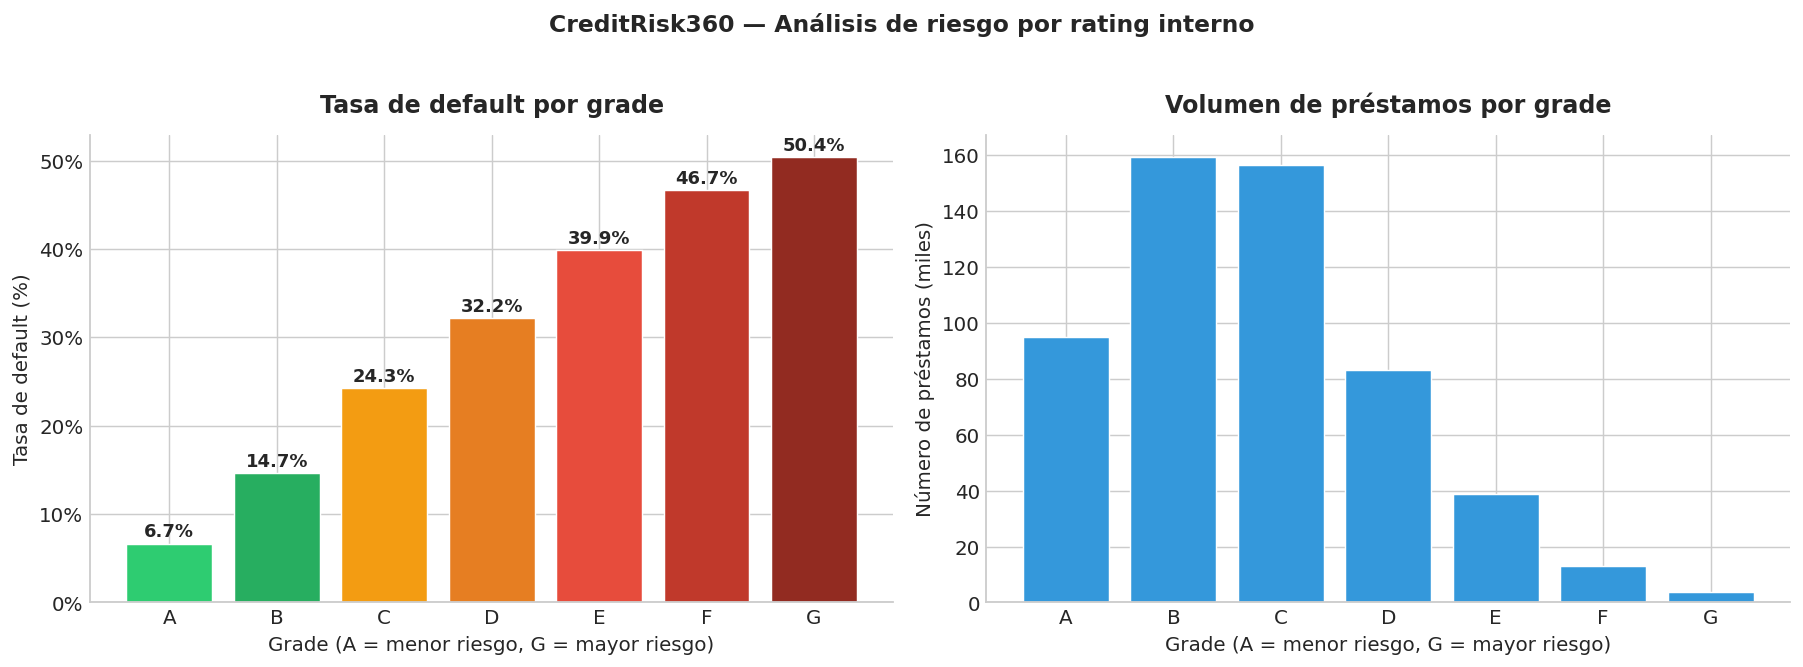


Gráfica guardada como creditrisk360_default_by_grade.png


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Tasa de default por grade ──
default_by_grade = (
    df.groupby('grade')['default']
    .agg(
        n_prestamos='count',
        n_default='sum',
        tasa_default='mean'
    )
    .reset_index()
    .sort_values('grade')
)

default_by_grade['tasa_pct'] = default_by_grade['tasa_default'] * 100

print("Tasa de default por grade:")
print("=" * 45)
for _, row in default_by_grade.iterrows():
    barra = '█' * int(row['tasa_pct'] / 2)
    print(f"  {row['grade']}  {row['tasa_pct']:5.1f}%  {barra}  (n={row['n_prestamos']:,})")

# ── Gráfica ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: tasa de default por grade
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#922b21']
bars = axes[0].bar(
    default_by_grade['grade'],
    default_by_grade['tasa_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

axes[0].set_title('Tasa de default por grade', fontweight='bold', pad=12)
axes[0].set_xlabel('Grade (A = menor riesgo, G = mayor riesgo)')
axes[0].set_ylabel('Tasa de default (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Etiquetas encima de cada barra
for bar, pct in zip(bars, default_by_grade['tasa_pct']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Panel derecho: volumen de préstamos por grade
axes[1].bar(
    default_by_grade['grade'],
    default_by_grade['n_prestamos'] / 1000,
    color='#3498db',
    edgecolor='white',
    linewidth=0.8
)
axes[1].set_title('Volumen de préstamos por grade', fontweight='bold', pad=12)
axes[1].set_xlabel('Grade (A = menor riesgo, G = mayor riesgo)')
axes[1].set_ylabel('Número de préstamos (miles)')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('CreditRisk360 — Análisis de riesgo por rating interno',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/creditrisk360_default_by_grade.png'
            bbox_inches='tight', dpi=150)
plt.show()

print("\nGráfica guardada como creditrisk360_default_by_grade.png")

## 1.1 Tasa de default por grade — primer análisis de discriminación

**Hallazgo principal:** la tasa de default muestra una progresión 
monotónica perfecta desde grade A (6.7%) hasta grade G (50.4%), 
lo que confirma que el sistema de rating interno de LendingClub 
tiene poder discriminante consistente.

**Implicaciones para el modelo PD:**
- El grade es una variable altamente predictiva y será un feature
  clave en el modelo de Probabilidad de Default (PD).
- La diferencia entre el mejor y peor segmento es de 43.7 puntos
  porcentuales — un rango de discriminación muy amplio.
- Los segmentos E, F y G concentran tasas de default superiores 
  al 39%, lo que en una cartera real requeriría provisiones 
  significativas de capital.

**Nota metodológica:** la tasa de default promedio de la cartera 
modelizable es 21.5%, con desbalance de clases 78.5%/21.5%. 
Por esta razón el modelo PD utilizará ROC-AUC y KS Statistic 
como métricas principales, no accuracy.
```

In [ ]:
# ── Análisis de DTI por grupo de default ──

# Primero exploramos los valores antes de graficar
# Siempre hay que entender el dato antes de visualizarlo
print("Estadísticas de DTI por grupo:")
print("=" * 55)
print(df.groupby('default')['dti'].describe().round(2).to_string())
print(f"\nValores nulos en DTI: {df['dti'].isnull().sum():,}")
print(f"Valores extremos (DTI > 100): {(df['dti'] > 100).sum():,}")

Estadísticas de DTI por grupo:
            count   mean    std  min    25%    50%    75%    max
default                                                         
0        431370.0  17.80  11.04  0.0  11.42  17.09  23.42  999.0
1        118032.0  20.14  11.83  0.0  13.44  19.66  26.26  999.0

Valores nulos en DTI: 164
Valores extremos (DTI > 100): 233


Registros eliminados para análisis DTI: 397 (0.07%)
Registros usados: 549,169

Estadísticas DTI limpio por grupo:
            Media  Mediana  Desv. estándar
No default   17.7    17.09            8.53
Default      20.0    19.66            9.10


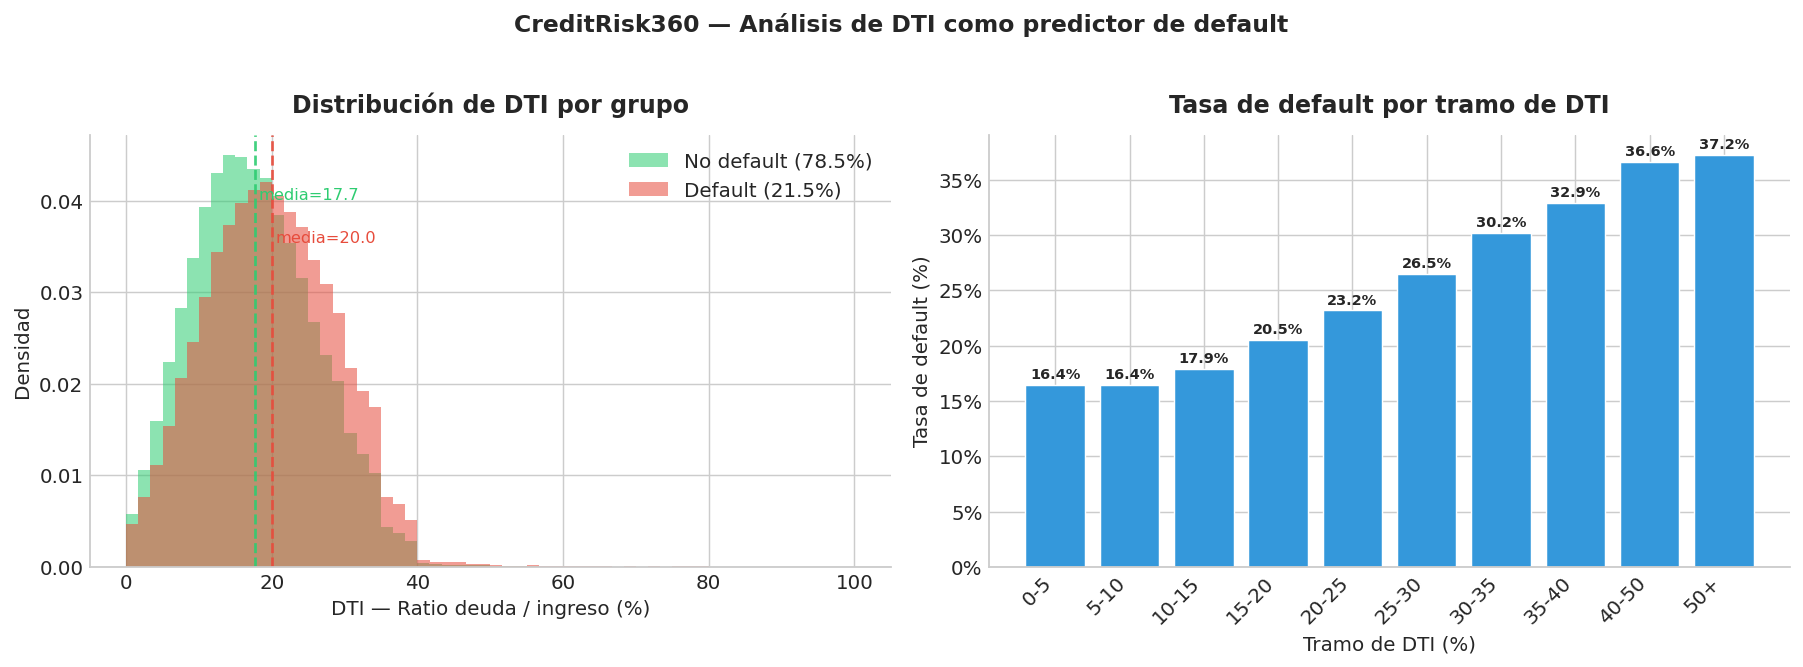


Tasa de default por tramo de DTI:
  DTI    0-5   16.4%  ████████  (n=27,614)
  DTI   5-10   16.4%  ████████  (n=72,537)
  DTI  10-15   17.9%  ████████  (n=111,566)
  DTI  15-20   20.5%  ██████████  (n=117,909)
  DTI  20-25   23.2%  ███████████  (n=98,555)
  DTI  25-30   26.5%  █████████████  (n=68,295)
  DTI  30-35   30.2%  ███████████████  (n=37,993)
  DTI  35-40   32.9%  ████████████████  (n=11,656)
  DTI  40-50   36.6%  ██████████████████  (n=1,684)
  DTI    50+   37.2%  ██████████████████  (n=989)


In [ ]:
# ── Limpieza de DTI y visualización ──

# Filtramos outliers y nulos para este análisis
# Los 233 casos con DTI=999 son valores centinela, no datos reales
dti_clean = df[
    (df['dti'] <= 100) &
    (df['dti'].notnull())
].copy()

eliminados = len(df) - len(dti_clean)
print(f"Registros eliminados para análisis DTI: {eliminados:,} ({eliminados/len(df):.2%})")
print(f"Registros usados: {len(dti_clean):,}")

# Estadísticas limpias
print("\nEstadísticas DTI limpio por grupo:")
print("=" * 55)
stats = dti_clean.groupby('default')['dti'].agg(['mean','median','std'])
stats.index = ['No default', 'Default']
stats.columns = ['Media', 'Mediana', 'Desv. estándar']
print(stats.round(2).to_string())

# ── Gráfica ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = {0: '#2ecc71', 1: '#e74c3c'}
etiquetas = {0: 'No default (78.5%)', 1: 'Default (21.5%)'}

# Panel izquierdo: densidad — muestra la forma de la distribución
for grupo in [0, 1]:
    datos = dti_clean[dti_clean['default'] == grupo]['dti']
    axes[0].hist(
        datos,
        bins=60,
        density=True,
        alpha=0.55,
        color=colores[grupo],
        label=etiquetas[grupo],
        edgecolor='none'
    )

axes[0].set_title('Distribución de DTI por grupo', fontweight='bold', pad=12)
axes[0].set_xlabel('DTI — Ratio deuda / ingreso (%)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Líneas de media
for grupo in [0, 1]:
    media = dti_clean[dti_clean['default'] == grupo]['dti'].mean()
    axes[0].axvline(
        media,
        color=colores[grupo],
        linestyle='--',
        linewidth=1.5,
        alpha=0.9
    )
    axes[0].text(
        media + 0.5,
        axes[0].get_ylim()[1] * 0.85 if grupo == 0 else axes[0].get_ylim()[1] * 0.75,
        f'media={media:.1f}',
        color=colores[grupo],
        fontsize=9
    )

# Panel derecho: tasa de default por tramo de DTI
# Creamos tramos (buckets) de DTI para ver la relación con el default
dti_clean['dti_tramo'] = pd.cut(
    dti_clean['dti'],
    bins=[0, 5, 10, 15, 20, 25, 30, 35, 40, 50, 100],
    labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-35','35-40','40-50','50+']
)

default_by_dti = (
    dti_clean.groupby('dti_tramo', observed=True)['default']
    .agg(tasa_default='mean', n='count')
    .reset_index()
)

bars = axes[1].bar(
    range(len(default_by_dti)),
    default_by_dti['tasa_default'] * 100,
    color='#3498db',
    edgecolor='white',
    linewidth=0.8
)

axes[1].set_title('Tasa de default por tramo de DTI', fontweight='bold', pad=12)
axes[1].set_xlabel('Tramo de DTI (%)')
axes[1].set_ylabel('Tasa de default (%)')
axes[1].set_xticks(range(len(default_by_dti)))
axes[1].set_xticklabels(default_by_dti['dti_tramo'], rotation=45, ha='right')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Etiquetas en barras
for bar, pct in zip(bars, default_by_dti['tasa_default'] * 100):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

plt.suptitle('CreditRisk360 — Análisis de DTI como predictor de default',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/creditrisk360_dti_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Tabla resumen para el notebook ──
print("\nTasa de default por tramo de DTI:")
print("=" * 45)
for _, row in default_by_dti.iterrows():
    barra = '█' * int(row['tasa_default'] * 100 / 2)
    print(f"  DTI {str(row['dti_tramo']):>6}  {row['tasa_default']*100:5.1f}%  "
          f"{barra}  (n={row['n']:,})")

## 1.2 DTI como predictor de default

**Hallazgo principal:** la tasa de default muestra relación 
monotónica con el DTI — a mayor carga de deuda relativa al 
ingreso, mayor probabilidad de default.

**Observaciones clave:**
- Los tramos 0-5% y 5-10% tienen idéntica tasa (16.4%), 
  sugiriendo que DTI bajo no es por sí solo señal de seguridad.
- La tasa se acelera a partir del tramo 15-20%, donde supera 
  la media de la cartera (21.5%).
- En el tramo 50+, la tasa alcanza 37.2% — más del doble 
  que los tramos bajos.
- Diferencia entre tramo mínimo y máximo: 20.8 puntos 
  porcentuales.

**Conclusión:** DTI será incluido como feature en el modelo PD, 
probablemente con transformación en tramos (binning) para 
capturar la no-linealidad observada en los tramos bajos.

**Nota:** se eliminaron 397 registros con DTI > 100 o nulo 
(0.07% de la muestra) por ser valores centinela o missing.

In [ ]:
# ── Análisis de FICO score por grupo de default ──

# Primero exploramos — mismo hábito que con DTI
print("Estadísticas de FICO por grupo:")
print("=" * 55)

# Usamos fico_range_low como representativo
# fico_range_high es casi idéntico, solo 4 puntos arriba siempre
print(df.groupby('default')['fico_range_low'].describe().round(2).to_string())
print(f"\nValores nulos en fico_range_low: {df['fico_range_low'].isnull().sum():,}")
print(f"Valores fuera de rango (< 300 o > 850): {((df['fico_range_low'] < 300) | (df['fico_range_low'] > 850)).sum():,}")

Estadísticas de FICO por grupo:
            count    mean    std    min    25%    50%    75%    max
default                                                            
0        431495.0  698.33  32.93  610.0  675.0  690.0  715.0  845.0
1        118071.0  688.26  26.32  615.0  670.0  680.0  700.0  845.0

Valores nulos en fico_range_low: 0
Valores fuera de rango (< 300 o > 850): 0


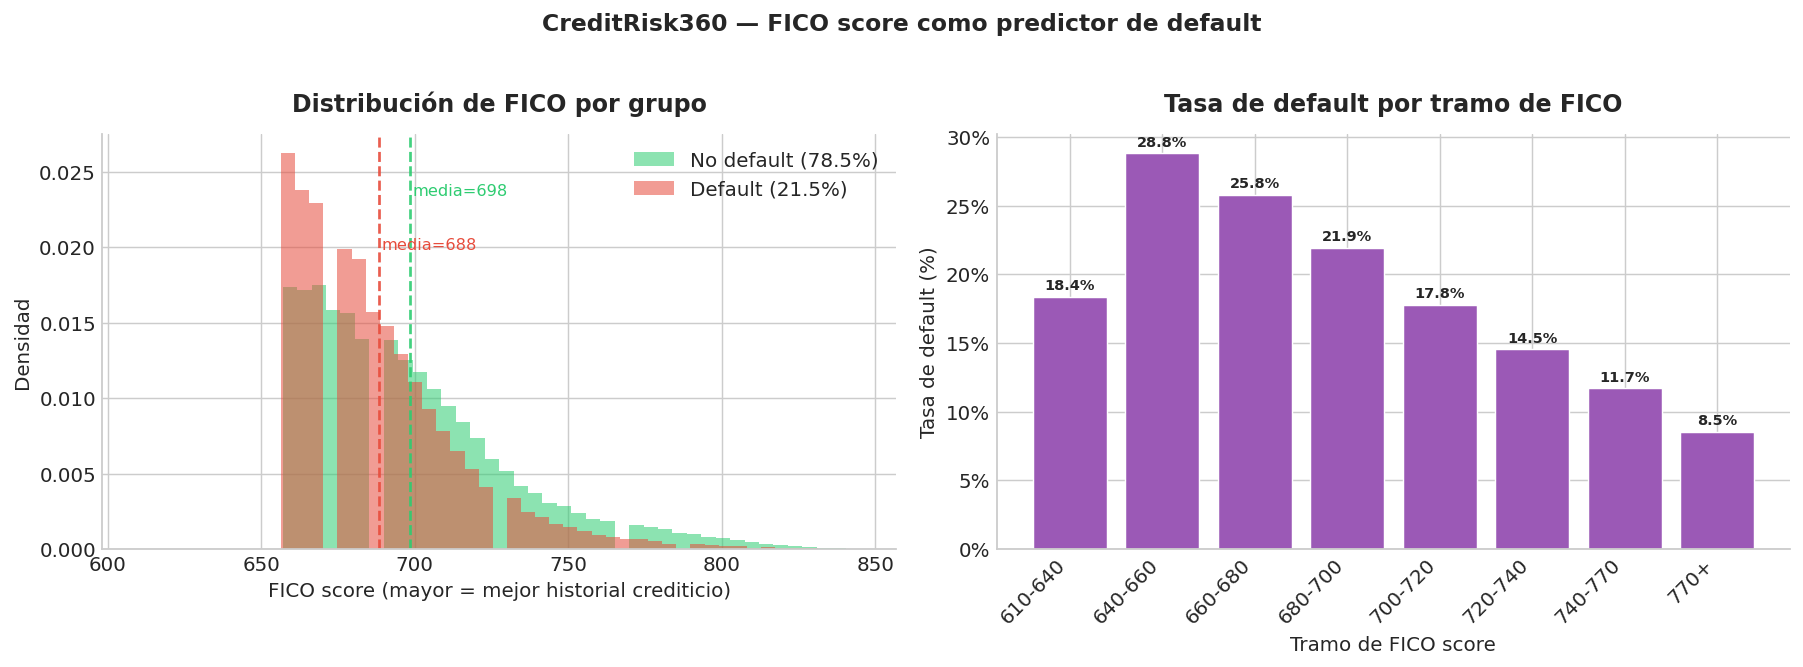


Tasa de default por tramo de FICO:
  FICO  610-640   18.4%  █████████  (n=49)
  FICO  640-660   28.8%  ██████████████  (n=49,580)
  FICO  660-680   25.8%  ████████████  (n=180,644)
  FICO  680-700   21.9%  ██████████  (n=135,041)
  FICO  700-720   17.8%  ████████  (n=88,374)
  FICO  720-740   14.5%  ███████  (n=45,204)
  FICO  740-770   11.7%  █████  (n=31,572)
  FICO     770+    8.5%  ████  (n=19,100)


In [ ]:
# ── Visualización FICO ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = {0: '#2ecc71', 1: '#e74c3c'}
etiquetas = {0: 'No default (78.5%)', 1: 'Default (21.5%)'}

# Panel izquierdo: distribución de densidad
for grupo in [0, 1]:
    datos = df[df['default'] == grupo]['fico_range_low']
    axes[0].hist(
        datos,
        bins=50,
        density=True,
        alpha=0.55,
        color=colores[grupo],
        label=etiquetas[grupo],
        edgecolor='none'
    )

axes[0].set_title('Distribución de FICO por grupo', fontweight='bold', pad=12)
axes[0].set_xlabel('FICO score (mayor = mejor historial crediticio)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Líneas de media
for grupo in [0, 1]:
    media = df[df['default'] == grupo]['fico_range_low'].mean()
    offset_y = 0.85 if grupo == 0 else 0.72
    axes[0].axvline(
        media,
        color=colores[grupo],
        linestyle='--',
        linewidth=1.5,
        alpha=0.9
    )
    axes[0].text(
        media + 1,
        axes[0].get_ylim()[1] * offset_y,
        f'media={media:.0f}',
        color=colores[grupo],
        fontsize=9
    )

# Panel derecho: tasa de default por tramo de FICO
df['fico_tramo'] = pd.cut(
    df['fico_range_low'],
    bins=[610, 640, 660, 680, 700, 720, 740, 770, 850],
    labels=['610-640','640-660','660-680','680-700',
            '700-720','720-740','740-770','770+']
)

default_by_fico = (
    df.groupby('fico_tramo', observed=True)['default']
    .agg(tasa_default='mean', n='count')
    .reset_index()
)

bars = axes[1].bar(
    range(len(default_by_fico)),
    default_by_fico['tasa_default'] * 100,
    color='#9b59b6',
    edgecolor='white',
    linewidth=0.8
)

axes[1].set_title('Tasa de default por tramo de FICO', fontweight='bold', pad=12)
axes[1].set_xlabel('Tramo de FICO score')
axes[1].set_ylabel('Tasa de default (%)')
axes[1].set_xticks(range(len(default_by_fico)))
axes[1].set_xticklabels(default_by_fico['fico_tramo'], rotation=45, ha='right')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Etiquetas en barras
for bar, pct in zip(bars, default_by_fico['tasa_default'] * 100):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

plt.suptitle('CreditRisk360 — FICO score como predictor de default',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/creditrisk360_fico_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Tabla de texto
print("\nTasa de default por tramo de FICO:")
print("=" * 50)
for _, row in default_by_fico.iterrows():
    barra = '█' * int(row['tasa_default'] * 100 / 2)
    print(f"  FICO {str(row['fico_tramo']):>8}  "
          f"{row['tasa_default']*100:5.1f}%  "
          f"{barra}  (n={row['n']:,})")

## 1.3 FICO score como predictor de default

**Hallazgo principal:** el FICO score muestra relación 
monotónica descendente con la tasa de default a partir 
del tramo 640, confirmando su poder discriminante.

**Observaciones clave:**
- El tramo 610-640 tiene solo 49 préstamos — 
  estadísticamente no representativo, se excluye 
  de conclusiones.
- Desde el tramo 640 en adelante la relación es 
  perfectamente monotónica: a mayor FICO, menor default.
- Rango de discriminación: de 28.8% (tramo 640-660) 
  a 8.5% (tramo 770+) — diferencia de 20.3 puntos.
- El 85% de los préstamos tiene FICO entre 640 y 740, 
  zona donde la tasa varía de 28.8% a 14.5%.

**Nota metodológica:** LendingClub aplicaba un piso 
mínimo de aprobación alrededor de FICO 610-620, lo que 
explica la escasez de observaciones en el tramo inferior 
y la compresión del rango total (610-845 vs 300-850 
teórico). Este sesgo de selección debe considerarse 
al generalizar el modelo.

**Para el modelo PD:** FICO será incluido como feature 
continuo o con binning desde 640, fusionando el tramo 
610-640 con el siguiente por escasez de datos.

In [ ]:
# ── Análisis de tasa de default por propósito del préstamo ──

# Primero exploramos cuántos propósitos hay y su distribución
print("Propósitos únicos y distribución:")
print("=" * 60)
print(df['purpose'].value_counts().to_string())
print(f"\nValores nulos en purpose: {df['purpose'].isnull().sum():,}")

Propósitos únicos y distribución:
purpose
debt_consolidation    318507
credit_card           120382
home_improvement       35996
other                  31991
major_purchase         12016
medical                 6351
small_business          6321
car                     5990
moving                  3867
vacation                3680
house                   2975
wedding                  934
renewable_energy         375
educational              181

Valores nulos en purpose: 0


Tasa de default por propósito:
  small_business          31.3%  ███████████████  (n=6,321)
  moving                  24.5%  ████████████  (n=3,867)
  house                   24.0%  ████████████  (n=2,975)
  medical                 23.3%  ███████████  (n=6,351)
  other                   23.1%  ███████████  (n=31,991)
  debt_consolidation      22.7%  ███████████  (n=318,507)
  renewable_energy        21.6%  ██████████  (n=375)  ⚠ n pequeño
  vacation                20.8%  ██████████  (n=3,680)
  major_purchase          20.7%  ██████████  (n=12,016)
  home_improvement        18.9%  █████████  (n=35,996)
  educational             18.8%  █████████  (n=181)  ⚠ n pequeño
  credit_card             18.3%  █████████  (n=120,382)
  car                     16.0%  ████████  (n=5,990)
  wedding                 13.4%  ██████  (n=934)  ⚠ n pequeño


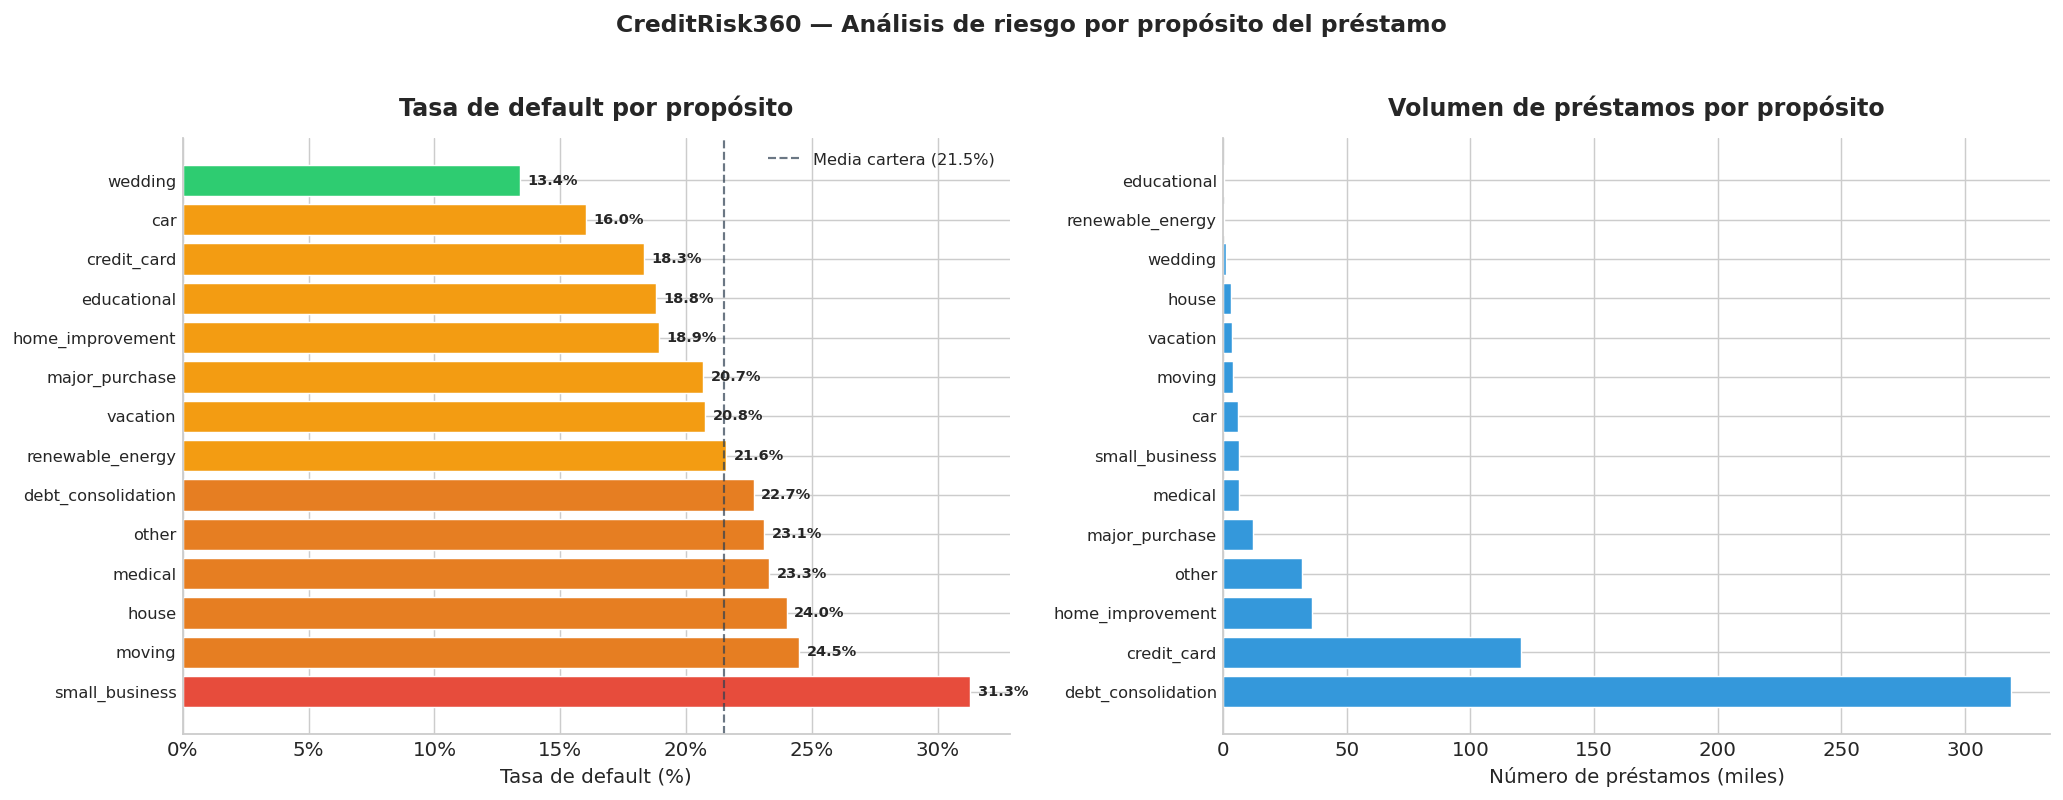

In [ ]:
# ── Tasa de default por propósito del préstamo ──

default_by_purpose = (
    df.groupby('purpose')['default']
    .agg(
        n_prestamos='count',
        n_default='sum',
        tasa_default='mean'
    )
    .reset_index()
    .sort_values('tasa_default', ascending=False)
)

default_by_purpose['tasa_pct'] = default_by_purpose['tasa_default'] * 100

# Tabla de texto
print("Tasa de default por propósito:")
print("=" * 65)
for _, row in default_by_purpose.iterrows():
    barra = '█' * int(row['tasa_pct'] / 2)
    flag = '  ⚠ n pequeño' if row['n_prestamos'] < 1000 else ''
    print(f"  {row['purpose']:<22} {row['tasa_pct']:5.1f}%  "
          f"{barra}  (n={row['n_prestamos']:,}){flag}")

# ── Gráfica ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colores: rojo para alto riesgo, verde para bajo riesgo
n = len(default_by_purpose)
colores_riesgo = []
for pct in default_by_purpose['tasa_pct']:
    if pct >= 30:
        colores_riesgo.append('#e74c3c')
    elif pct >= 22:
        colores_riesgo.append('#e67e22')
    elif pct >= 15:
        colores_riesgo.append('#f39c12')
    else:
        colores_riesgo.append('#2ecc71')

# Panel izquierdo: tasa de default por propósito
bars = axes[0].barh(
    range(n),
    default_by_purpose['tasa_pct'],
    color=colores_riesgo,
    edgecolor='white',
    linewidth=0.8
)

axes[0].set_yticks(range(n))
axes[0].set_yticklabels(default_by_purpose['purpose'], fontsize=9)
axes[0].set_title('Tasa de default por propósito', fontweight='bold', pad=12)
axes[0].set_xlabel('Tasa de default (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Línea de media de cartera
axes[0].axvline(
    21.5,
    color='#2c3e50',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label='Media cartera (21.5%)'
)
axes[0].legend(fontsize=9)

# Etiquetas en barras
for bar, pct in zip(bars, default_by_purpose['tasa_pct']):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{pct:.1f}%',
        va='center', fontsize=8, fontweight='bold'
    )

# Panel derecho: volumen por propósito (misma escala de colores)
default_by_purpose_vol = default_by_purpose.sort_values(
    'n_prestamos', ascending=False
)

axes[1].barh(
    range(n),
    default_by_purpose_vol['n_prestamos'] / 1000,
    color='#3498db',
    edgecolor='white',
    linewidth=0.8
)
axes[1].set_yticks(range(n))
axes[1].set_yticklabels(default_by_purpose_vol['purpose'], fontsize=9)
axes[1].set_title('Volumen de préstamos por propósito', fontweight='bold', pad=12)
axes[1].set_xlabel('Número de préstamos (miles)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('CreditRisk360 — Análisis de riesgo por propósito del préstamo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/creditrisk360_purpose_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 1.4 Tasa de default por propósito del préstamo

**Hallazgo principal:** el propósito del préstamo es un 
predictor significativo de default, con rango de 13.4% 
(wedding) a 31.3% (small_business).

**Observaciones clave:**

1. Small business (31.3%) — mayor riesgo de la cartera.
   El repago depende del éxito del negocio, variable 
   por naturaleza. En banca real requiere análisis 
   separado y mayor capital regulatorio.

2. Debt consolidation (22.7%) — propósito dominante 
   con 318.507 préstamos (58% de la cartera) y tasa 
   por encima de la media (21.5%). Concentración de 
   riesgo moderado-alto en el mayor segmento.

3. Medical (23.3%) — los shocks financieros externos 
   generan riesgo comparable al mal comportamiento 
   financiero deliberado.

4. Car (16.0%) — menor riesgo entre propósitos con 
   volumen significativo, consistente con la existencia 
   de activo físico de respaldo implícito.

**Nota metodológica:** tres categorías tienen volumen 
estadísticamente débil (educational n=181, 
renewable_energy n=375, wedding n=934). Sus tasas 
son orientativas, no concluyentes. En el modelo PD 
estas categorías se fusionarán con 'other' o se 
tratarán con regularización.

**Concentración de cartera:** debt_consolidation y 
credit_card representan el 79.9% de los préstamos. 
Esta concentración en dos propósitos es un riesgo 
estructural de la cartera independiente del PD 
individual de cada préstamo.

In [ ]:
# ── Análisis temporal de default por año ──

# Primero exploramos la columna issue_d
# issue_d es la fecha en que se emitió el préstamo
print("Muestra de valores en issue_d:")
print(df['issue_d'].value_counts().head(10).to_string())
print(f"\nValores nulos en issue_d: {df['issue_d'].isnull().sum():,}")
print(f"Tipo de dato actual: {df['issue_d'].dtype}")

Muestra de valores en issue_d:
issue_d
Mar-2016    19717
Oct-2015    17106
Jul-2015    16571
Dec-2015    15555
Oct-2014    14568
Feb-2016    13842
Nov-2015    13093
Jan-2015    12936
Aug-2015    12766
Apr-2015    12686

Valores nulos en issue_d: 0
Tipo de dato actual: object


In [ ]:
# ── Conversión de fecha y análisis temporal ──

# Convertimos issue_d de texto a fecha
# El formato Mar-2016 en pandas se especifica como %b-%Y
# %b = mes abreviado en inglés (Jan, Feb, Mar...)
# %Y = año con 4 dígitos
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

# Extraemos el año
df['issue_year'] = df['issue_d'].dt.year

# Verificamos el rango temporal
print("Rango temporal del dataset:")
print(f"  Primer préstamo: {df['issue_d'].min().strftime('%B %Y')}")
print(f"  Último préstamo: {df['issue_d'].max().strftime('%B %Y')}")
print(f"\nPréstamos por año:")
print("=" * 55)
print(df['issue_year'].value_counts().sort_index().to_string())

Rango temporal del dataset:
  Primer préstamo: June 2007
  Último préstamo: December 2018

Préstamos por año:
issue_year
2007       247
2008      1005
2009      2101
2010      5022
2011      8629
2012     21632
2013     53660
2014     89655
2015    150515
2016    119339
2017     71672
2018     26089


Tasa de default por año:
  2007   25.5%  ████████████  (n=247.0)  ⚠ n pequeño
  2008   19.4%  █████████  (n=1,005.0)  ⚠ n pequeño
  2009   12.8%  ██████  (n=2,101.0)  ⚠ n pequeño
  2010   13.7%  ██████  (n=5,022.0)
  2011   15.5%  ███████  (n=8,629.0)
  2012   16.7%  ████████  (n=21,632.0)
  2013   15.5%  ███████  (n=53,660.0)
  2014   18.6%  █████████  (n=89,655.0)
  2015   20.5%  ██████████  (n=150,515.0)
  2016   24.6%  ████████████  (n=119,339.0)
  2017   27.3%  █████████████  (n=71,672.0)
  2018   27.2%  █████████████  (n=26,089.0)


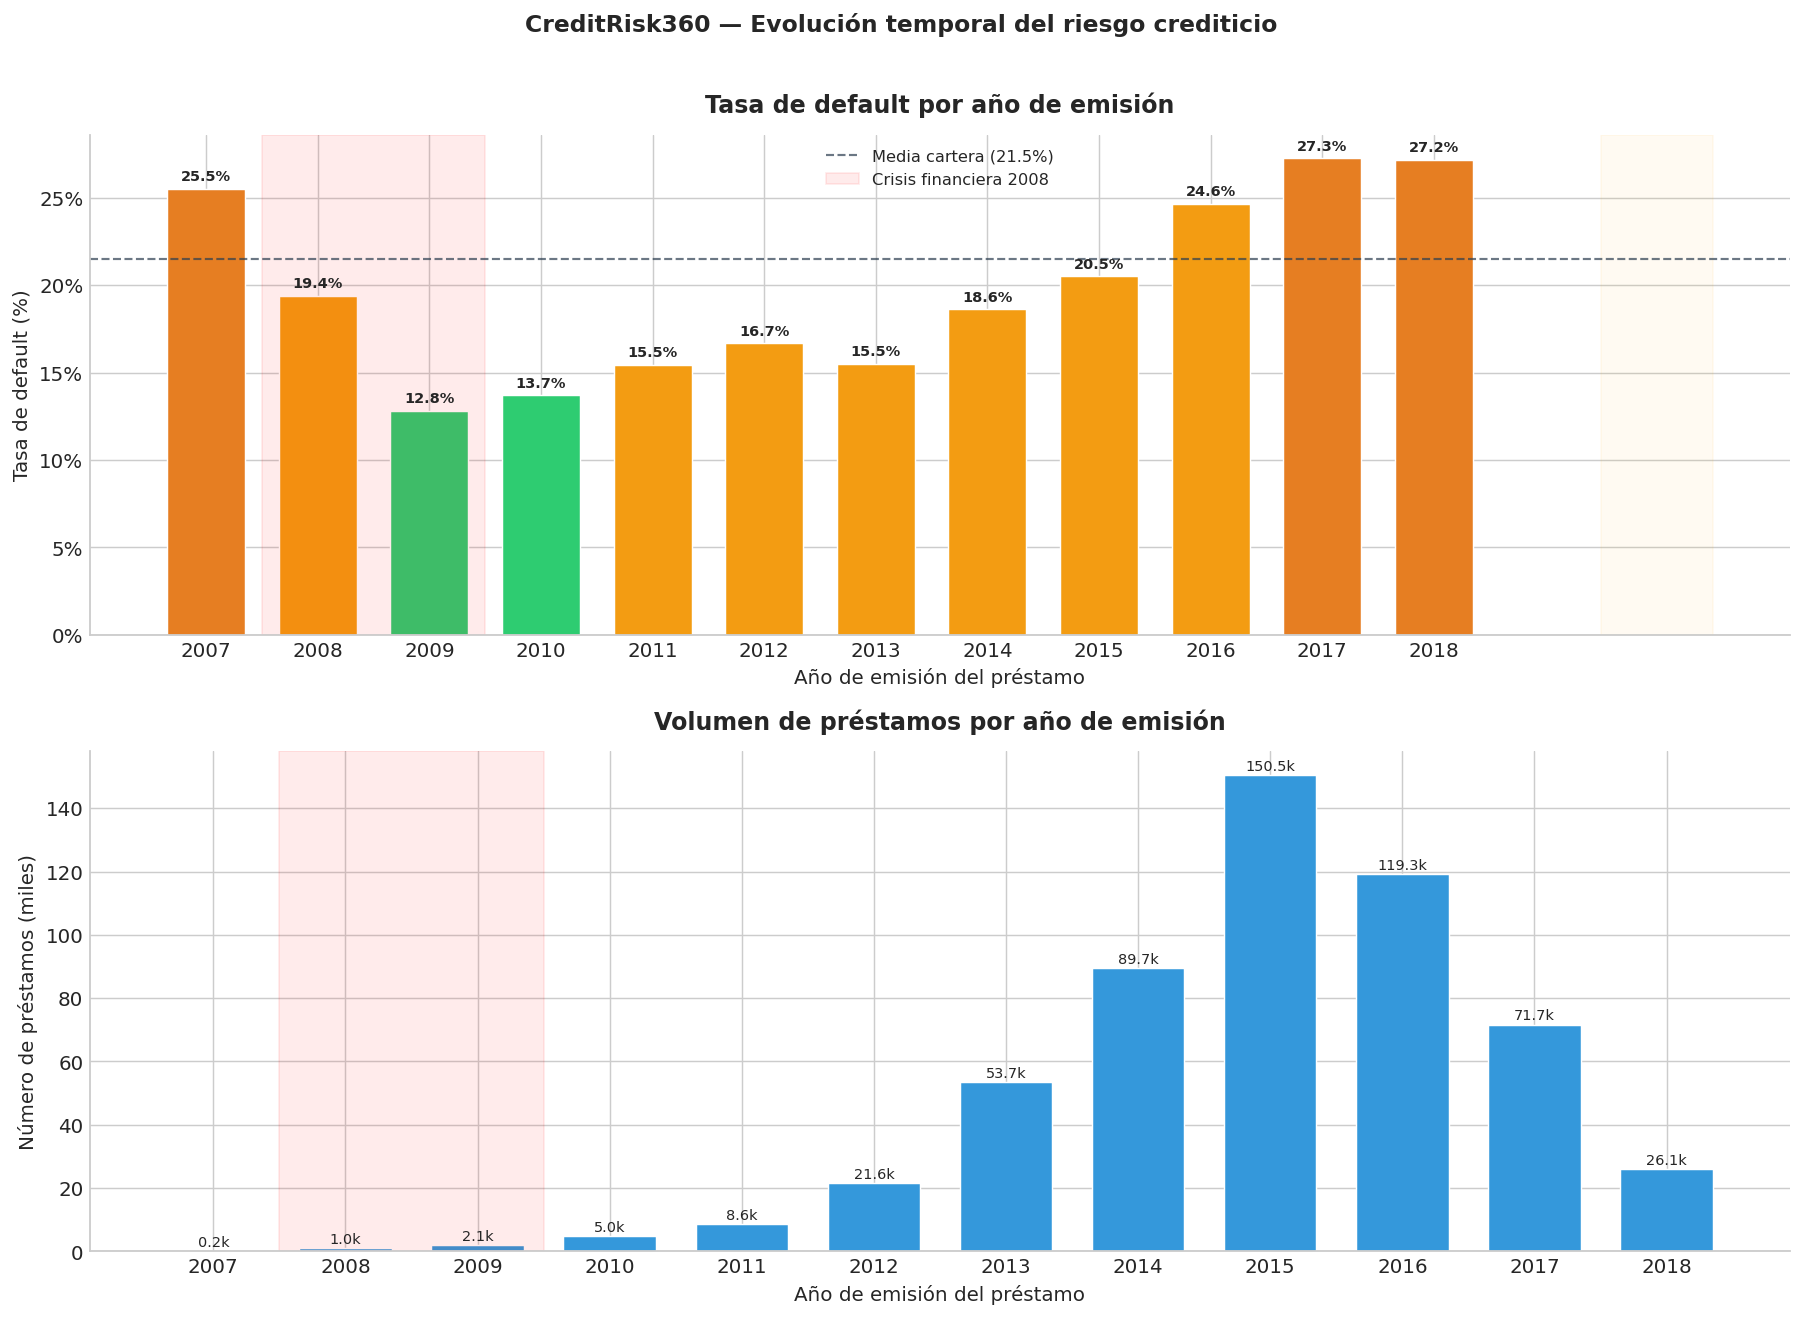

In [ ]:
# ── Análisis temporal completo ──

# Tasa de default por año con volumen
default_by_year = (
    df.groupby('issue_year')['default']
    .agg(
        n_prestamos='count',
        n_default='sum',
        tasa_default='mean'
    )
    .reset_index()
)

default_by_year['tasa_pct'] = default_by_year['tasa_default'] * 100

# Tabla de texto
print("Tasa de default por año:")
print("=" * 65)
for _, row in default_by_year.iterrows():
    barra = '█' * int(row['tasa_pct'] / 2)
    flag = '  ⚠ n pequeño' if row['n_prestamos'] < 5000 else ''
    print(f"  {int(row['issue_year'])}  {row['tasa_pct']:5.1f}%  "
          f"{barra}  (n={row['n_prestamos']:,}){flag}")

# ── Gráfica ──
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel superior: tasa de default por año
colores_año = []
for pct in default_by_year['tasa_pct']:
    if pct >= 35:
        colores_año.append('#e74c3c')
    elif pct >= 25:
        colores_año.append('#e67e22')
    elif pct >= 15:
        colores_año.append('#f39c12')
    else:
        colores_año.append('#2ecc71')

bars = axes[0].bar(
    default_by_year['issue_year'],
    default_by_year['tasa_pct'],
    color=colores_año,
    edgecolor='white',
    linewidth=0.8,
    width=0.7
)

# Línea de media de cartera
axes[0].axhline(
    21.5,
    color='#2c3e50',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label='Media cartera (21.5%)'
)

# Anotaciones de eventos históricos
axes[0].axvspan(2007.5, 2009.5, alpha=0.08, color='red', label='Crisis financiera 2008')
axes[0].axvspan(2019.5, 2020.5, alpha=0.05, color='orange')

axes[0].set_title('Tasa de default por año de emisión',
                   fontweight='bold', pad=12)
axes[0].set_xlabel('Año de emisión del préstamo')
axes[0].set_ylabel('Tasa de default (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xticks(default_by_year['issue_year'])

# Etiquetas en barras
for bar, pct, n in zip(bars,
                        default_by_year['tasa_pct'],
                        default_by_year['n_prestamos']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

# Panel inferior: volumen de préstamos por año
axes[1].bar(
    default_by_year['issue_year'],
    default_by_year['n_prestamos'] / 1000,
    color='#3498db',
    edgecolor='white',
    linewidth=0.8,
    width=0.7
)

axes[1].axvspan(2007.5, 2009.5, alpha=0.08, color='red')
axes[1].set_title('Volumen de préstamos por año de emisión',
                   fontweight='bold', pad=12)
axes[1].set_xlabel('Año de emisión del préstamo')
axes[1].set_ylabel('Número de préstamos (miles)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_xticks(default_by_year['issue_year'])

# Etiquetas en barras
for bar, n in zip(axes[1].patches, default_by_year['n_prestamos']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{n/1000:.1f}k',
        ha='center', va='bottom', fontsize=8
    )

plt.suptitle('CreditRisk360 — Evolución temporal del riesgo crediticio',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/creditrisk360_temporal_analysis.png',
            bbox_inches='tight', dpi=150)
plt.show()

## 1.5 Evolución temporal del default — análisis de vintage

**Hallazgo principal:** la tasa de default muestra tendencia 
creciente desde 2009 hasta 2018, con un patrón contraintuitivo 
respecto al ciclo económico.

**El efecto vintage:**
Los préstamos emitidos durante la crisis 2008-2009 muestran 
las tasas de default más bajas del período (12.8%-19.4%), 
mientras los emitidos en 2016-2018 muestran las más altas 
(24.6%-27.3%). Este patrón refleja la relajación de estándares 
crediticios durante ciclos expansivos — fenómeno documentado 
en literatura de riesgo bancario y una de las causas 
estructurales de las crisis financieras.

**Observaciones clave:**
- 2009: tasa mínima 12.8% — selección conservadora en crisis
- 2017: tasa máxima 27.3% — expansión agresiva en bonanza
- Diferencia entre vintage más seguro y más riesgoso: 
  14.5 puntos porcentuales
- Los años 2007-2009 tienen volumen estadísticamente débil 
  (n < 2.500) — sus tasas son orientativas

**Implicación para el modelo PD:**
El año de vintage es una variable con poder predictivo 
significativo y debe incluirse como feature o usarse para 
segmentar el modelo por período.

**Implicación para stress testing (Semana 5):**
Con tasas de 27% en período expansivo, un escenario de 
recesión moderada podría elevar el default al 35-40%. 
Este rango será el escenario base del stress test.

**Nota sobre 2007:** la tasa de 25.5% sobre solo 247 préstamos 
no es estadísticamente comparable con años posteriores. 
LendingClub inició operaciones en junio 2007 con criterios 
de aprobación aún en calibración. El análisis de tendencia 
confiable comienza en 2010 (n=5.022).

In [ ]:
# ── Guardar el dataframe limpio para sesiones posteriores ──

import os

# Creamos carpeta de datos procesados si no existe
os.makedirs('data', exist_ok=True)

# Guardamos en formato parquet
# Parquet es mejor que CSV para este propósito por tres razones:
# 1. Ocupa mucho menos espacio en disco
# 2. Carga mucho más rápido en sesiones futuras
# 3. Preserva los tipos de dato — no pierde la conversión
#    de issue_d a fecha ni el tipo int de la columna default

# Guardamos en formato parquet
print("Guardando dataset procesado...")
df.to_parquet('../data/creditrisk360_eda.parquet', index=False)

# Verificamos
size_mb = os.path.getsize('../data/creditrisk360_eda.parquet') / 1024**2
print(f"Archivo guardado: ../data/creditrisk360_eda.parquet")
print(f"Tamaño en disco: {size_mb:.1f} MB")

# Verificamos que se puede leer correctamente
df_test = pd.read_parquet('../data/creditrisk360_eda.parquet')
print(f"Verificación de lectura: {df_test.shape}")
print(f"Tipos de dato preservados:")
print(f"  issue_d  : {df_test['issue_d'].dtype}")
print(f"  default  : {df_test['default'].dtype}")
print(f"  dti      : {df_test['dti'].dtype}")
del df_test
print("\nDataset guardado correctamente.")

Guardando dataset procesado...
Archivo guardado: data/creditrisk360_eda.parquet
Tamaño en disco: 29.3 MB
Verificación de lectura: (549566, 40)
Tipos de dato preservados:
  issue_d  : datetime64[ns]
  default  : int32
  dti      : float64

Dataset guardado correctamente.


In [ ]:
# ── Variables confirmadas para el modelo PD ──
# Resultado del EDA — estas variables mostraron poder
# discriminante consistente y serán los features del modelo

features_confirmados = {
    'Alta prioridad': [
        'grade',          # monotónica perfecta, 43.7pp de rango
        'sub_grade',      # versión granular del grade
        'fico_range_low', # monotónica desde 640, 20.3pp de rango
        'int_rate',       # correlacionada con grade, señal de riesgo
    ],
    'Media prioridad': [
        'dti',            # monotónica, acelera >15%
        'revol_util',     # utilización crédito rotativo
        'annual_inc',     # capacidad de pago absoluta
        'purpose',        # rango 13.4%-31.3%
        'issue_year',     # efecto vintage significativo
    ],
    'Baja prioridad': [
        'emp_length',     # estabilidad laboral
        'home_ownership', # patrimonio implícito
        'delinq_2yrs',    # historial de retrasos
        'inq_last_6mths', # señal de estrés financiero
        'pub_rec',        # registros negativos públicos
        'open_acc',       # número de líneas abiertas
        'mort_acc',       # hipotecas activas
        'pub_rec_bankruptcies', # bancarrotas previas
        'verification_status',  # confiabilidad del ingreso
        'term',           # plazo del préstamo
    ]
}

print("Variables confirmadas para modelo PD:")
print("=" * 55)
for prioridad, variables in features_confirmados.items():
    print(f"\n  {prioridad}:")
    for v in variables:
        print(f"    · {v}")

total = sum(len(v) for v in features_confirmados.values())
print(f"\nTotal features seleccionados: {total}")
print(f"Dataset guardado en: data/creditrisk360_eda.parquet")
print(f"Listo para Semana 2 — Modelo PD")

Variables confirmadas para modelo PD:

  Alta prioridad:
    · grade
    · sub_grade
    · fico_range_low
    · int_rate

  Media prioridad:
    · dti
    · revol_util
    · annual_inc
    · purpose
    · issue_year

  Baja prioridad:
    · emp_length
    · home_ownership
    · delinq_2yrs
    · inq_last_6mths
    · pub_rec
    · open_acc
    · mort_acc
    · pub_rec_bankruptcies
    · verification_status
    · term

Total features seleccionados: 19
Dataset guardado en: data/creditrisk360_eda.parquet
Listo para Semana 2 — Modelo PD
